# Linear Regression Single-Trajectory Estimation: SGD vs Full-Batch GD

This notebook studies the Appendix B coupled setting on a single linear-regression trajectory. We compare one SGD run against the matched full-batch GD trajectory on the same dataset and fit a **scalar ridge penalty** rather than a full matrix.

For the stored SGD states `\hat\theta_t`, define the observed and predictable Appendix B targets

- `b_t = \eta^{-1}(\hat\theta_t - \hat\theta_{t+1}) - \eta^{-1}(\theta_t - \theta_{t+1})`
- `b_t^* = \nabla L(\hat\theta_t) - \nabla L(\theta_t)`

Restrict the model class to `R_\lambda(\theta) = (\lambda/2) \|\theta\|_2^2`, so `\nabla R_\lambda(\theta) = \lambda \theta`. The notebook then:

1. generates one coupled SGD/GD trajectory,
2. estimates the scalar ridge coefficient from progressively longer trajectory prefixes,
3. visualizes the empirical estimate `\hat\lambda_t` and oracle estimate `\lambda_t^*` against timestep, and
4. plots the empirical and oracle Appendix B losses side by side.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from IPython.display import display

ROOT = Path.cwd()
if not (ROOT / "figures").exists() and (ROOT.parent / "figures").exists():
    ROOT = ROOT.parent

FIG_DIR = ROOT / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

style_path = ROOT / "clean_fig.mplstyle"
if style_path.exists():
    plt.style.use(style_path)


In [2]:
def mse_grad(X: torch.Tensor, y: torch.Tensor, theta: torch.Tensor) -> torch.Tensor:
    n = X.shape[0]
    return X.T @ (X @ theta - y) / n


def mse_grad_trajectory(X: torch.Tensor, y: torch.Tensor, thetas: torch.Tensor) -> torch.Tensor:
    n = X.shape[0]
    c = (X.T @ y) / n
    A = (X.T @ X) / n
    return thetas @ A.T - c.unsqueeze(0)


def batch_grad(X: torch.Tensor, y: torch.Tensor, theta: torch.Tensor, idx: torch.Tensor) -> torch.Tensor:
    Xb = X[idx]
    yb = y[idx]
    n = Xb.shape[0]
    return Xb.T @ (Xb @ theta - yb) / n


def gd_trajectory(X: torch.Tensor, y: torch.Tensor, steps: int, lr: float) -> torch.Tensor:
    theta = torch.zeros(X.shape[1], dtype=X.dtype)
    thetas = [theta.clone()]
    for _ in range(steps):
        theta = theta - lr * mse_grad(X, y, theta)
        thetas.append(theta.clone())
    return torch.stack(thetas)


def sgd_trajectory(
    X: torch.Tensor,
    y: torch.Tensor,
    steps: int,
    lr: float,
    batch_size: int,
    generator: torch.Generator,
) -> torch.Tensor:
    theta = torch.zeros(X.shape[1], dtype=X.dtype)
    thetas = [theta.clone()]
    n = X.shape[0]
    for _ in range(steps):
        idx = torch.randint(n, (batch_size,), generator=generator)
        theta = theta - lr * batch_grad(X, y, theta, idx)
        thetas.append(theta.clone())
    return torch.stack(thetas)


def fit_scalar_ridge_from_points(theta_points: torch.Tensor, target_points: torch.Tensor) -> torch.Tensor:
    numer = (theta_points * target_points).sum()
    denom = theta_points.square().sum().clamp_min(1e-12)
    return numer / denom


def fit_scalar_ridge_from_trajectory(
    theta_points: torch.Tensor,
    target_points: torch.Tensor,
    steps_used: int,
    burn_in: int = 0,
) -> torch.Tensor:
    if steps_used <= burn_in:
        raise ValueError("steps_used must be greater than burn_in")
    return fit_scalar_ridge_from_points(theta_points[burn_in:steps_used], target_points[burn_in:steps_used])


def appendix_b_loss(
    theta_points: torch.Tensor,
    target_points: torch.Tensor,
    lam,
    burn_in: int = 0,
    steps_used = None,
    average: bool = True,
) -> float:
    end = theta_points.shape[0] if steps_used is None else steps_used
    if end <= burn_in:
        raise ValueError("steps_used must be greater than burn_in")
    lam_tensor = torch.as_tensor(lam, dtype=theta_points.dtype, device=theta_points.device)
    residual = target_points[burn_in:end] - lam_tensor * theta_points[burn_in:end]
    per_step_sq_norm = residual.square().sum(dim=1)
    return per_step_sq_norm.mean().item() if average else per_step_sq_norm.sum().item()


def plot_trace(
    ax: plt.Axes,
    x: np.ndarray,
    y: np.ndarray,
    title: str,
    xlabel: str,
    ylabel: str,
    color: str,
    label: str,
    linestyle: str = "-",
    logy: bool = False,
):
    plot_y = np.maximum(y, 1e-12) if logy else y
    plot_fn = ax.semilogy if logy else ax.plot
    plot_fn(x, plot_y, color=color, linewidth=2.0, label=label, linestyle=linestyle)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.3, which="both")


In [3]:
SEED = 56
P = 10
N = 1000
LR = 1e-2
STEPS = 1000
BATCH_SIZE = 8
BURN_IN = 50


torch.manual_seed(SEED)
np.random.seed(SEED)
torch.use_deterministic_algorithms(False)

X = torch.randn(N, P)
g = torch.Generator().manual_seed(SEED + 1)
beta = 3.0 * torch.randn(P, generator=g)
y = X @ beta

theta_gd = gd_trajectory(X, y, STEPS, LR)
full_grad_gd = mse_grad_trajectory(X, y, theta_gd)

g = torch.Generator().manual_seed(SEED + 100)
theta_sgd = sgd_trajectory(X, y, STEPS, LR, BATCH_SIZE, g)
theta_points = theta_sgd[:-1]
b_obs = (theta_sgd[:-1] - theta_sgd[1:]) / LR - (theta_gd[:-1] - theta_gd[1:]) / LR
b_star = mse_grad_trajectory(X, y, theta_points) - full_grad_gd[:-1]

lambda_empirical_final = fit_scalar_ridge_from_trajectory(theta_points, b_obs, STEPS, burn_in=BURN_IN)
lambda_oracle_final = fit_scalar_ridge_from_trajectory(theta_points, b_star, STEPS, burn_in=BURN_IN)

print(f"Single-trajectory burn-in: {BURN_IN} steps")
print(f"Stored SGD trajectory shape: {theta_sgd.shape}")
print(f"Final empirical scalar ridge estimate: {lambda_empirical_final.item():.6f}")
print(f"Final oracle scalar ridge estimate: {lambda_oracle_final.item():.6f}")
print(f"Final estimate gap: {abs(lambda_empirical_final.item() - lambda_oracle_final.item()):.6f}")


Single-trajectory burn-in: 50 steps
Stored SGD trajectory shape: torch.Size([1001, 10])
Final empirical scalar ridge estimate: 0.001635
Final oracle scalar ridge estimate: 0.004768
Final estimate gap: 0.003132


## 1) Coupled SGD-vs-GD trajectory on one run

The first figure tracks the norm gap between the SGD and full-batch GD iterates and compares the observed Appendix B target `b_t` against its predictable counterpart `b_t^*` along the stored trajectory.


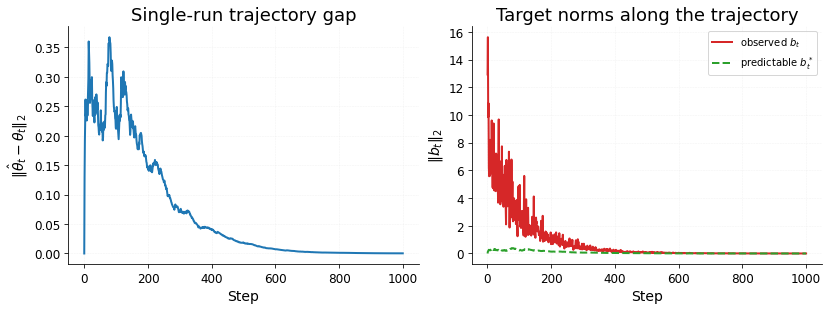

linear_regression_sgd_vs_gd_trajectory_gap.pdf


In [4]:
steps = torch.arange(STEPS + 1)
trajectory_gap_norm = torch.linalg.norm(theta_sgd - theta_gd, dim=1)
observed_target_norm = torch.linalg.norm(b_obs, dim=1)
predictable_target_norm = torch.linalg.norm(b_star, dim=1)

fig_gap_path = FIG_DIR / "linear_regression_sgd_vs_gd_trajectory_gap.pdf"
fig, axes = plt.subplots(1, 2, figsize=(11.4, 4.2), constrained_layout=True)

axes[0].plot(steps.numpy(), trajectory_gap_norm.numpy(), color="#1f77b4", linewidth=2.0)
axes[0].set_title("Single-run trajectory gap")
axes[0].set_xlabel("Step")
axes[0].set_ylabel(r"$\|\hat{\theta}_t - \theta_t\|_2$")
axes[0].grid(alpha=0.3)

traj_steps = torch.arange(1, STEPS + 1)
axes[1].plot(traj_steps.numpy(), observed_target_norm.numpy(), color="#d62728", linewidth=2.0, label="observed $b_t$")
axes[1].plot(traj_steps.numpy(), predictable_target_norm.numpy(), color="#2ca02c", linewidth=2.0, linestyle="--", label="predictable $b_t^*$")
axes[1].set_title("Target norms along the trajectory")
axes[1].set_xlabel("Step")
axes[1].set_ylabel(r"$\|b_t\|_2$")
axes[1].grid(alpha=0.3)
axes[1].legend()

fig.savefig(fig_gap_path, bbox_inches="tight")
display(fig)
plt.close(fig)

print(fig_gap_path.name)


## 2) Scalar ridge estimate against timestep

Restrict the regularizer to `R_\lambda(\theta) = (\lambda/2)\|\theta\|_2^2`, so fitting Appendix B reduces to one scalar least-squares coefficient.

For each retained prefix `m = BURN_IN + 1, \ldots, T`, estimate:

- `\hat\lambda_m` from the observed targets `b_t`
- `\lambda_m^*` from the predictable targets `b_t^*`

The next plot shows how those scalar estimates evolve as more trajectory steps are included.


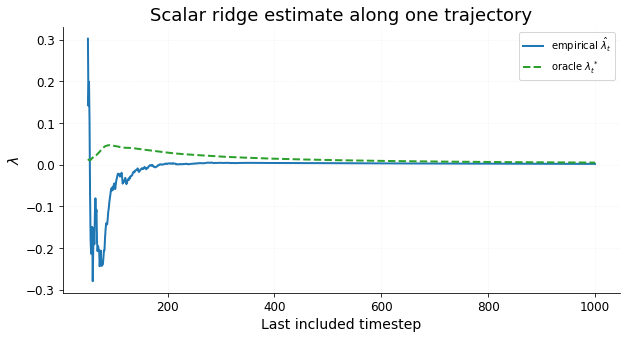

empirical scalar ridge estimate at timestep 51: 0.302001
empirical scalar ridge estimate at timestep 1000: 0.001635
oracle scalar ridge estimate at timestep 51: 0.013104
oracle scalar ridge estimate at timestep 1000: 0.004768
linear_regression_sgd_vs_gd_ridge_lambda_trace.pdf


In [5]:
retained_steps = torch.arange(BURN_IN + 1, STEPS + 1)
lambda_empirical_trace = torch.empty(len(retained_steps))
lambda_oracle_trace = torch.empty(len(retained_steps))

for i, steps_used in enumerate(retained_steps.tolist()):
    lambda_empirical_trace[i] = fit_scalar_ridge_from_trajectory(theta_points, b_obs, steps_used, burn_in=BURN_IN)
    lambda_oracle_trace[i] = fit_scalar_ridge_from_trajectory(theta_points, b_star, steps_used, burn_in=BURN_IN)

fig_lambda_path = FIG_DIR / "linear_regression_sgd_vs_gd_ridge_lambda_trace.pdf"
fig, ax = plt.subplots(figsize=(8.6, 4.6), constrained_layout=True)

plot_trace(
    ax,
    retained_steps.numpy(),
    lambda_empirical_trace.numpy(),
    title="Scalar ridge estimate along one trajectory",
    xlabel="Last included timestep",
    ylabel=r"$\lambda$",
    color="#1f77b4",
    label=r"empirical $\hat{\lambda}_t$",
)
plot_trace(
    ax,
    retained_steps.numpy(),
    lambda_oracle_trace.numpy(),
    title="Scalar ridge estimate along one trajectory",
    xlabel="Last included timestep",
    ylabel=r"$\lambda$",
    color="#2ca02c",
    label=r"oracle $\lambda_t^*$",
    linestyle="--",
)
ax.legend()

fig.savefig(fig_lambda_path, bbox_inches="tight")
display(fig)
plt.close(fig)

print(f"empirical scalar ridge estimate at timestep {retained_steps[0].item()}: {lambda_empirical_trace[0].item():.6f}")
print(f"empirical scalar ridge estimate at timestep {retained_steps[-1].item()}: {lambda_empirical_trace[-1].item():.6f}")
print(f"oracle scalar ridge estimate at timestep {retained_steps[0].item()}: {lambda_oracle_trace[0].item():.6f}")
print(f"oracle scalar ridge estimate at timestep {retained_steps[-1].item()}: {lambda_oracle_trace[-1].item():.6f}")
print(fig_lambda_path.name)


## 3) Empirical and oracle losses

The Appendix B losses are now shown side by side, both on the same retained trajectory prefixes.

To keep prefixes comparable, the plotted values are **per-step averages** rather than raw sums:

- left: empirical loss `\hat E_m(\lambda)/(m-BURN_IN)`
- right: oracle loss `E_m(\lambda)/(m-BURN_IN)`

Each panel compares the empirical-fit scalar `\hat\lambda_m` against the oracle-fit scalar `\lambda_m^*`.


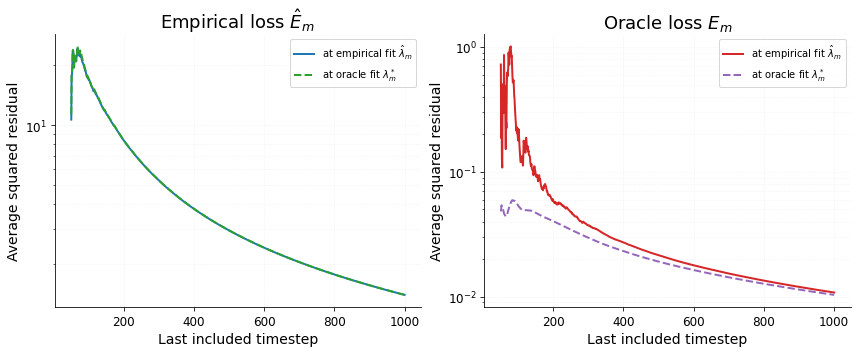

final empirical loss at empirical fit: 1.397964
final empirical loss at oracle fit: 1.398426
final oracle loss at empirical fit: 0.010815
final oracle loss at oracle fit: 0.010354
linear_regression_sgd_vs_gd_ridge_losses.pdf


In [6]:
empirical_loss_empirical_fit = torch.empty(len(retained_steps))
empirical_loss_oracle_fit = torch.empty(len(retained_steps))
oracle_loss_empirical_fit = torch.empty(len(retained_steps))
oracle_loss_oracle_fit = torch.empty(len(retained_steps))

for i, steps_used in enumerate(retained_steps.tolist()):
    lam_hat = lambda_empirical_trace[i]
    lam_star = lambda_oracle_trace[i]
    empirical_loss_empirical_fit[i] = appendix_b_loss(theta_points, b_obs, lam_hat, burn_in=BURN_IN, steps_used=steps_used, average=True)
    empirical_loss_oracle_fit[i] = appendix_b_loss(theta_points, b_obs, lam_star, burn_in=BURN_IN, steps_used=steps_used, average=True)
    oracle_loss_empirical_fit[i] = appendix_b_loss(theta_points, b_star, lam_hat, burn_in=BURN_IN, steps_used=steps_used, average=True)
    oracle_loss_oracle_fit[i] = appendix_b_loss(theta_points, b_star, lam_star, burn_in=BURN_IN, steps_used=steps_used, average=True)

fig_loss_path = FIG_DIR / "linear_regression_sgd_vs_gd_ridge_losses.pdf"
fig, axes = plt.subplots(1, 2, figsize=(11.8, 4.8), constrained_layout=True)

plot_trace(
    axes[0],
    retained_steps.numpy(),
    empirical_loss_empirical_fit.numpy(),
    title=r"Empirical loss $\hat{E}_m$",
    xlabel="Last included timestep",
    ylabel="Average squared residual",
    color="#1f77b4",
    label=r"at empirical fit $\hat{\lambda}_m$",
    logy=True,
)
plot_trace(
    axes[0],
    retained_steps.numpy(),
    empirical_loss_oracle_fit.numpy(),
    title=r"Empirical loss $\hat{E}_m$",
    xlabel="Last included timestep",
    ylabel="Average squared residual",
    color="#2ca02c",
    label=r"at oracle fit $\lambda_m^*$",
    linestyle="--",
    logy=True,
)
axes[0].legend()

plot_trace(
    axes[1],
    retained_steps.numpy(),
    oracle_loss_empirical_fit.numpy(),
    title=r"Oracle loss $E_m$",
    xlabel="Last included timestep",
    ylabel="Average squared residual",
    color="#d62728",
    label=r"at empirical fit $\hat{\lambda}_m$",
    logy=True,
)
plot_trace(
    axes[1],
    retained_steps.numpy(),
    oracle_loss_oracle_fit.numpy(),
    title=r"Oracle loss $E_m$",
    xlabel="Last included timestep",
    ylabel="Average squared residual",
    color="#9467bd",
    label=r"at oracle fit $\lambda_m^*$",
    linestyle="--",
    logy=True,
)
axes[1].legend()

fig.savefig(fig_loss_path, bbox_inches="tight")
display(fig)
plt.close(fig)

print(f"final empirical loss at empirical fit: {empirical_loss_empirical_fit[-1].item():.6f}")
print(f"final empirical loss at oracle fit: {empirical_loss_oracle_fit[-1].item():.6f}")
print(f"final oracle loss at empirical fit: {oracle_loss_empirical_fit[-1].item():.6f}")
print(f"final oracle loss at oracle fit: {oracle_loss_oracle_fit[-1].item():.6f}")
print(fig_loss_path.name)


In [7]:
print(fig_gap_path)
print(fig_lambda_path)
print(fig_loss_path)


/home/kevin/OneDrive/Documents/UMich/Research/inductive-bias/figures/linear_regression_sgd_vs_gd_trajectory_gap.pdf
/home/kevin/OneDrive/Documents/UMich/Research/inductive-bias/figures/linear_regression_sgd_vs_gd_ridge_lambda_trace.pdf
/home/kevin/OneDrive/Documents/UMich/Research/inductive-bias/figures/linear_regression_sgd_vs_gd_ridge_losses.pdf
